# 04 MNIST CNN — 畳み込みニューラルネットワーク入門

## このノートブックで学ぶこと

1. **テンソルの形状変化** — Conv2d・MaxPool2d・flatten を通過するたびにテンソルの shape がどう変わるかを毎ステップ追う
2. **CNN のアーキテクチャ** — 2 つの畳み込みブロックと全結合層で MNIST 10 クラス分類を行う
3. **学習の流れ** — DataLoader / optimizer / criterion を組み合わせた標準的な訓練ループ
4. **中間特徴マップの可視化** — Conv1・Conv2 が「何を見ているか」を画像として確認する
5. **カーネル重みの可視化** — 学習前後でフィルタがどう変化するかを比較する

In [7]:
# Cell 1 — Setup
import struct
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

print(f"torch version : {torch.__version__}")
print(f"numpy version : {np.__version__}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device        : {device}")

torch version : 2.5.1+cu121
numpy version : 2.1.3
device        : cuda


## CNN 形状変化の図解

各層を通過するごとにテンソルの shape がどう変わるかを整理します。

```bash
入力           :  (N,  1, 28, 28)   ← バッチサイズ N, チャンネル 1, 28×28 ピクセル
Conv2d(1→32)   :  (N, 32, 28, 28)   ← padding=1 で空間サイズ保持
ReLU           :  (N, 32, 28, 28)
MaxPool2d(2×2) :  (N, 32, 14, 14)   ← 空間サイズ 1/2
Conv2d(32→64)  :  (N, 64, 14, 14)   ← padding=1 で空間サイズ保持
ReLU           :  (N, 64, 14, 14)
MaxPool2d(2×2) :  (N, 64,  7,  7)   ← 空間サイズ 1/2
flatten        :  (N, 3136)          ← 64 × 7 × 7 = 3136
Linear(3136→128):  (N, 128)
ReLU           :  (N, 128)
Linear(128→10) :  (N, 10)           ← 10 クラスの logit
```

### Conv2d の出力サイズ計算式

$$\text{out\_size} = \frac{\text{in\_size} + 2 \times \text{pad} - \text{kernel}}{\text{stride}} + 1$$

**padding=1 により空間サイズが保たれる理由:**

$$\frac{28 + 2 \times 1 - 3}{1} + 1 = \frac{28}{1} = 28 \quad \checkmark$$

padding を 0 にすると $28 - 3 + 1 = 26$ に縮んでしまいます。
padding=1 にすることで入力と同じ 28×28 を維持できます。

**MaxPool2d(2×2) の効果:**  
2×2 領域の最大値を 1 値に集約 → 空間サイズが 1/2 に。  
$28 \to 14 \to 7$ と 2 回プーリングすることで受容野を広げ、位置不変性を得ます。

train images : (60000, 28, 28), dtype=uint8
train labels : (60000,)
test  images : (10000, 28, 28)
test  labels : (10000,)


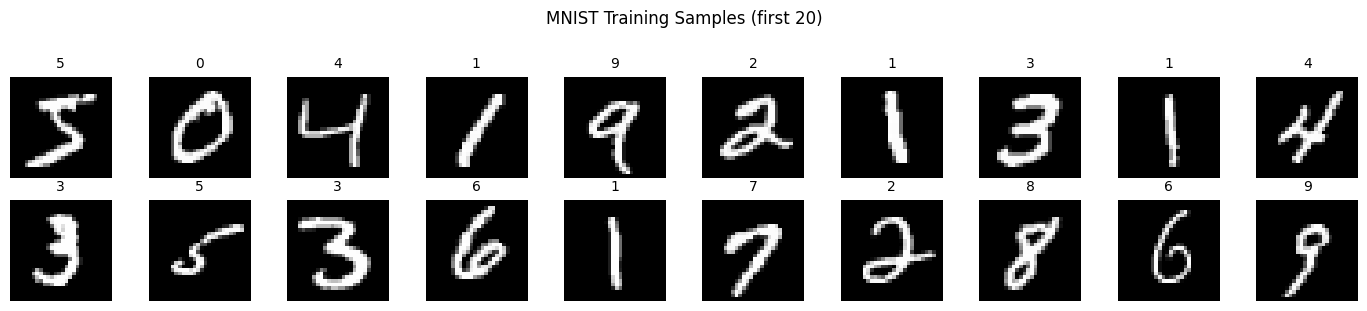

In [8]:
# Cell 3 — MNIST ローダー
DATA_DIR = '../data/mnist'

def load_mnist_images(path):
    """idx3 形式の画像バイナリを numpy array (N, 28, 28) として読み込む"""
    with open(path, 'rb') as f:
        magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
    assert magic == 2051, f"magic number mismatch: {magic}"
    with open(path, 'rb') as f:
        f.read(16)
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)

def load_mnist_labels(path):
    """idx1 形式のラベルバイナリを numpy array (N,) として読み込む"""
    with open(path, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
    assert magic == 2049, f"magic number mismatch: {magic}"
    with open(path, 'rb') as f:
        f.read(8)
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

# 読み込み
train_images = load_mnist_images(f'{DATA_DIR}/train-images-idx3-ubyte')
train_labels = load_mnist_labels(f'{DATA_DIR}/train-labels-idx1-ubyte')
test_images  = load_mnist_images(f'{DATA_DIR}/t10k-images-idx3-ubyte')
test_labels  = load_mnist_labels(f'{DATA_DIR}/t10k-labels-idx1-ubyte')

print(f"train images : {train_images.shape}, dtype={train_images.dtype}")
print(f"train labels : {train_labels.shape}")
print(f"test  images : {test_images.shape}")
print(f"test  labels : {test_labels.shape}")

# サンプル 20 枚グリッド表示
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title(str(train_labels[i]), fontsize=10)
    ax.axis('off')
fig.suptitle('MNIST Training Samples (first 20)', y=1.02)
plt.tight_layout()
plt.show()

## Conv の形状計算を数値で確認

計算式 $\text{out} = (\text{in} + 2p - k) / s + 1$ に数値を代入して確認します。

| 層 | 入力サイズ | pad | kernel | stride | 出力サイズ | 計算 |
|---|---|---|---|---|---|---|
| Conv1 | 28 | 1 | 3 | 1 | **28** | (28+2-3)/1+1=28 |
| Pool1 | 28 | 0 | 2 | 2 | **14** | (28+0-2)/2+1=14 |
| Conv2 | 14 | 1 | 3 | 1 | **14** | (14+2-3)/1+1=14 |
| Pool2 | 14 | 0 | 2 | 2 | **7**  | (14+0-2)/2+1=7  |

Pool2 後のテンソル形状: `(N, 64, 7, 7)`  
flatten 後: `64 × 7 × 7 = 3136` 次元のベクトル

In [9]:
# Cell 5 — モデル定義
class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x, debug=False):
        def _p(name, t):
            if debug:
                print(f"{name:<12}: {tuple(t.shape)}")

        _p("入力", x)
        x = self.relu(self.conv1(x)); _p("Conv1", x)
        x = self.pool(x);            _p("Pool1", x)
        x = self.relu(self.conv2(x)); _p("Conv2", x)
        x = self.pool(x);            _p("Pool2", x)
        x = x.flatten(1);            _p("Flatten", x)
        x = self.relu(self.fc1(x));  _p("FC1", x)
        x = self.fc2(x);             _p("FC2", x)
        return x

model = MnistCNN().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

MnistCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters    : 421,642
Trainable parameters: 421,642


In [10]:
# Cell 6 — 形状確認（ドライラン）
x_dummy = torch.zeros(1, 1, 28, 28).to(device)
print("=== Dry run (batch=1, debug=True) ===")
with torch.no_grad():
    _ = model(x_dummy, debug=True)

=== Dry run (batch=1, debug=True) ===
入力          : (1, 1, 28, 28)
Conv1       : (1, 32, 28, 28)
Pool1       : (1, 32, 14, 14)
Conv2       : (1, 64, 14, 14)
Pool2       : (1, 64, 7, 7)
Flatten     : (1, 3136)
FC1         : (1, 128)
FC2         : (1, 10)


In [11]:
# Cell 7 — Dataset / DataLoader
class MnistDataset(Dataset):
    def __init__(self, images, labels):
        # (N, 28, 28) uint8 → (N, 1, 28, 28) float32, 正規化 [0, 1]
        self.x = torch.tensor(images[:, None, :, :] / 255.0, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = MnistDataset(train_images, train_labels)
test_ds  = MnistDataset(test_images,  test_labels)

train_loader = DataLoader(train_ds, batch_size=64,  shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

# shape 確認
xb, yb = next(iter(train_loader))
print(f"batch x : {xb.shape}  dtype={xb.dtype}")
print(f"batch y : {yb.shape}  dtype={yb.dtype}")
print(f"pixel range: [{xb.min():.3f}, {xb.max():.3f}]")

batch x : torch.Size([64, 1, 28, 28])  dtype=torch.float32
batch y : torch.Size([64])  dtype=torch.int64
pixel range: [0.000, 1.000]


Epochs:   0%|          | 0/5 [00:00<?, ?epoch/s]

  Train 1/5:   0%|          | 0/938 [00:00<?, ?batch/s]

  Test  1/5:   0%|          | 0/40 [00:00<?, ?batch/s]

  Train 2/5:   0%|          | 0/938 [00:00<?, ?batch/s]

  Test  2/5:   0%|          | 0/40 [00:00<?, ?batch/s]

...

  Test  3/5:   0%|          | 0/40 [00:00<?, ?batch/s]

  Train 4/5:   0%|          | 0/938 [00:00<?, ?batch/s]

  Test  4/5:   0%|          | 0/40 [00:00<?, ?batch/s]

  Train 5/5:   0%|          | 0/938 [00:00<?, ?batch/s]

  Test  5/5:   0%|          | 0/40 [00:00<?, ?batch/s]

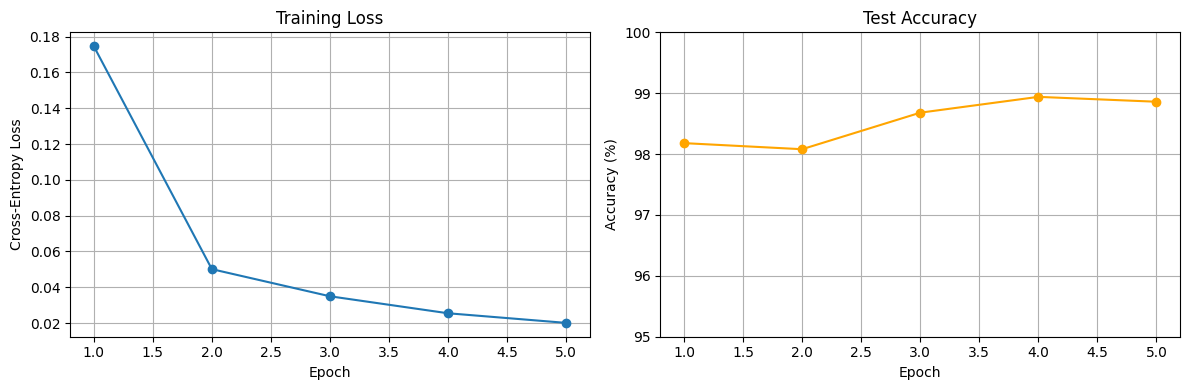

最終テスト精度: 98.86%


In [12]:
# Cell 8 — 学習ループ
# 学習前の Conv1 重みを保存（Cell 12 で比較用）
init_conv1_weight = model.conv1.weight.data.clone()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 5
train_losses = []
test_accs    = []

epoch_bar = tqdm(range(1, EPOCHS + 1), desc='Epochs', unit='epoch')
for epoch in epoch_bar:
    # --- 訓練 ---
    model.train()
    running_loss = 0.0
    train_bar = tqdm(train_loader, desc=f'  Train {epoch}/{EPOCHS}',
                     leave=False, unit='batch')
    for xb, yb in train_bar:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(xb)
        train_bar.set_postfix(loss=f'{loss.item():.4f}')
    epoch_loss = running_loss / len(train_ds)
    train_losses.append(epoch_loss)

    # --- テスト精度 ---
    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc=f'  Test  {epoch}/{EPOCHS}',
                            leave=False, unit='batch'):
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
    acc = correct / len(test_ds) * 100
    test_accs.append(acc)

    epoch_bar.set_postfix(loss=f'{epoch_loss:.4f}', acc=f'{acc:.2f}%')

print()
# --- プロット ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, EPOCHS+1), train_losses, marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True)

ax2.plot(range(1, EPOCHS+1), test_accs, marker='o', color='orange')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(95, 100)
ax2.grid(True)

plt.tight_layout()
plt.show()
print(f"最終テスト精度: {test_accs[-1]:.2f}%")

## 特徴マップとは

**特徴マップ (feature map)** とは、Conv 層が入力に対してフィルタ（カーネル）を適用して得られる出力テンソルです。

- Conv1 の 32 チャンネルは「エッジ」「テクスチャ」など低レベルな特徴を捉えます
- Conv2 の 64 チャンネルはそれらを組み合わせた「曲線」「部分的なパターン」など中レベルの特徴を捉えます

特徴マップを可視化することで:
1. モデルが何を「見ているか」を直感的に理解できる
2. 過学習・デバッグの手掛かりになる
3. CNN が画像の局所パターンを階層的に学習する様子を確認できる

以下では **forward hook** を使って、推論中の中間出力を副作用なく取得します。

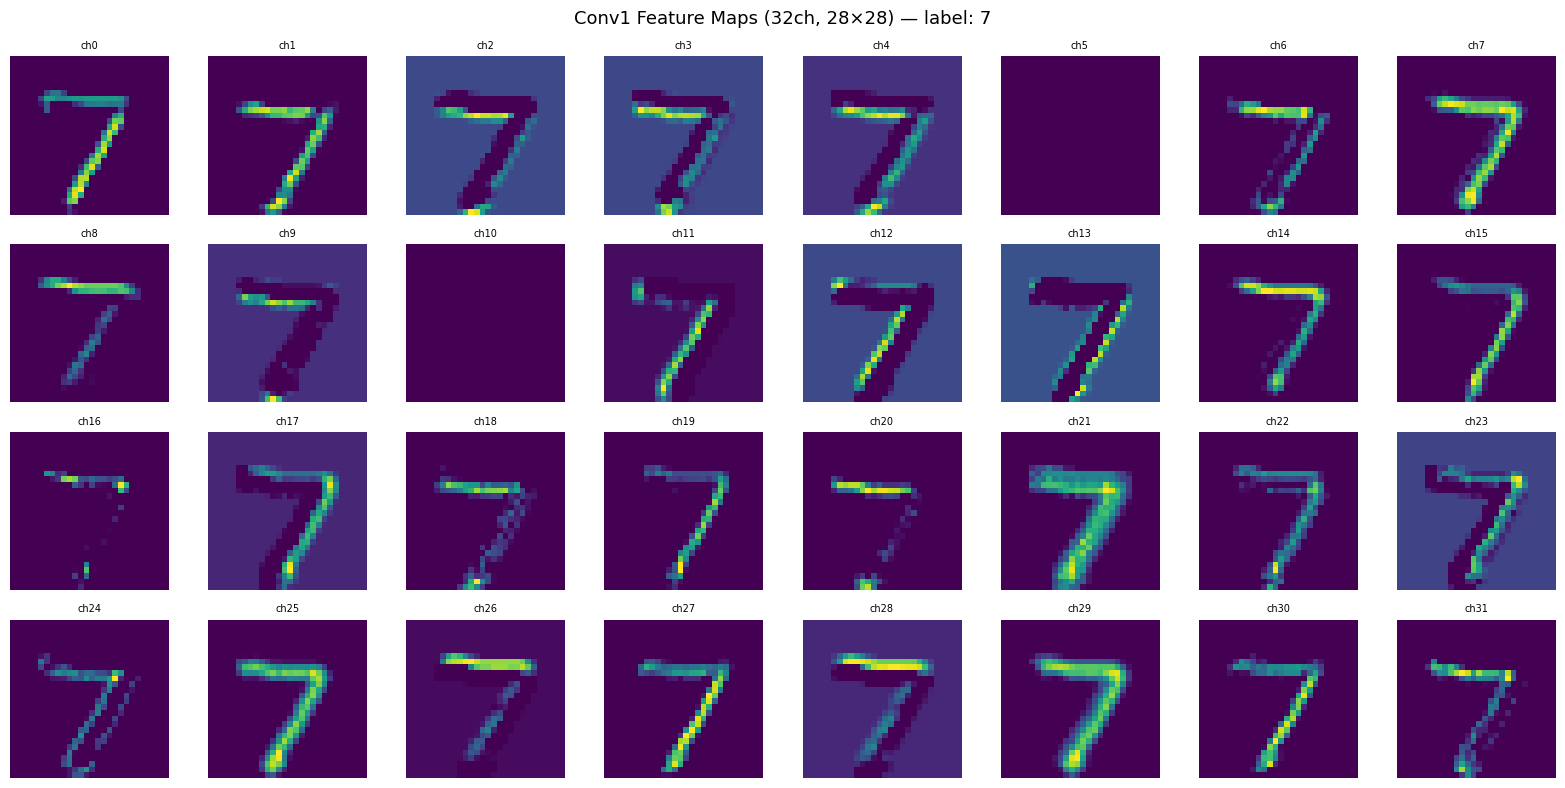

Conv1 特徴マップ shape: (32, 28, 28)  (ch, H, W)


In [13]:
# Cell 10 — 特徴マップ可視化（Conv1）
# テスト画像 1 枚を選択
sample_img = test_ds[0][0].unsqueeze(0).to(device)  # (1, 1, 28, 28)
sample_lbl = test_labels[0]

conv1_out = {}
conv2_out = {}

def make_hook(store):
    def hook(module, input, output):
        store['out'] = output.detach()
    return hook

h1 = model.conv1.register_forward_hook(make_hook(conv1_out))
h2 = model.conv2.register_forward_hook(make_hook(conv2_out))

model.eval()
with torch.no_grad():
    _ = model(sample_img)

h1.remove()
h2.remove()

# Conv1 後（ReLU 前）の特徴マップ → ReLU を手動適用
fm1 = torch.relu(conv1_out['out']).squeeze(0).cpu().numpy()  # (32, 28, 28)

# 32 チャンネルを 4×8 グリッドで表示
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle(f'Conv1 Feature Maps (32ch, 28×28) — label: {sample_lbl}', fontsize=13)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fm1[i], cmap='viridis')
    ax.set_title(f'ch{i}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Conv1 特徴マップ shape: {fm1.shape}  (ch, H, W)")

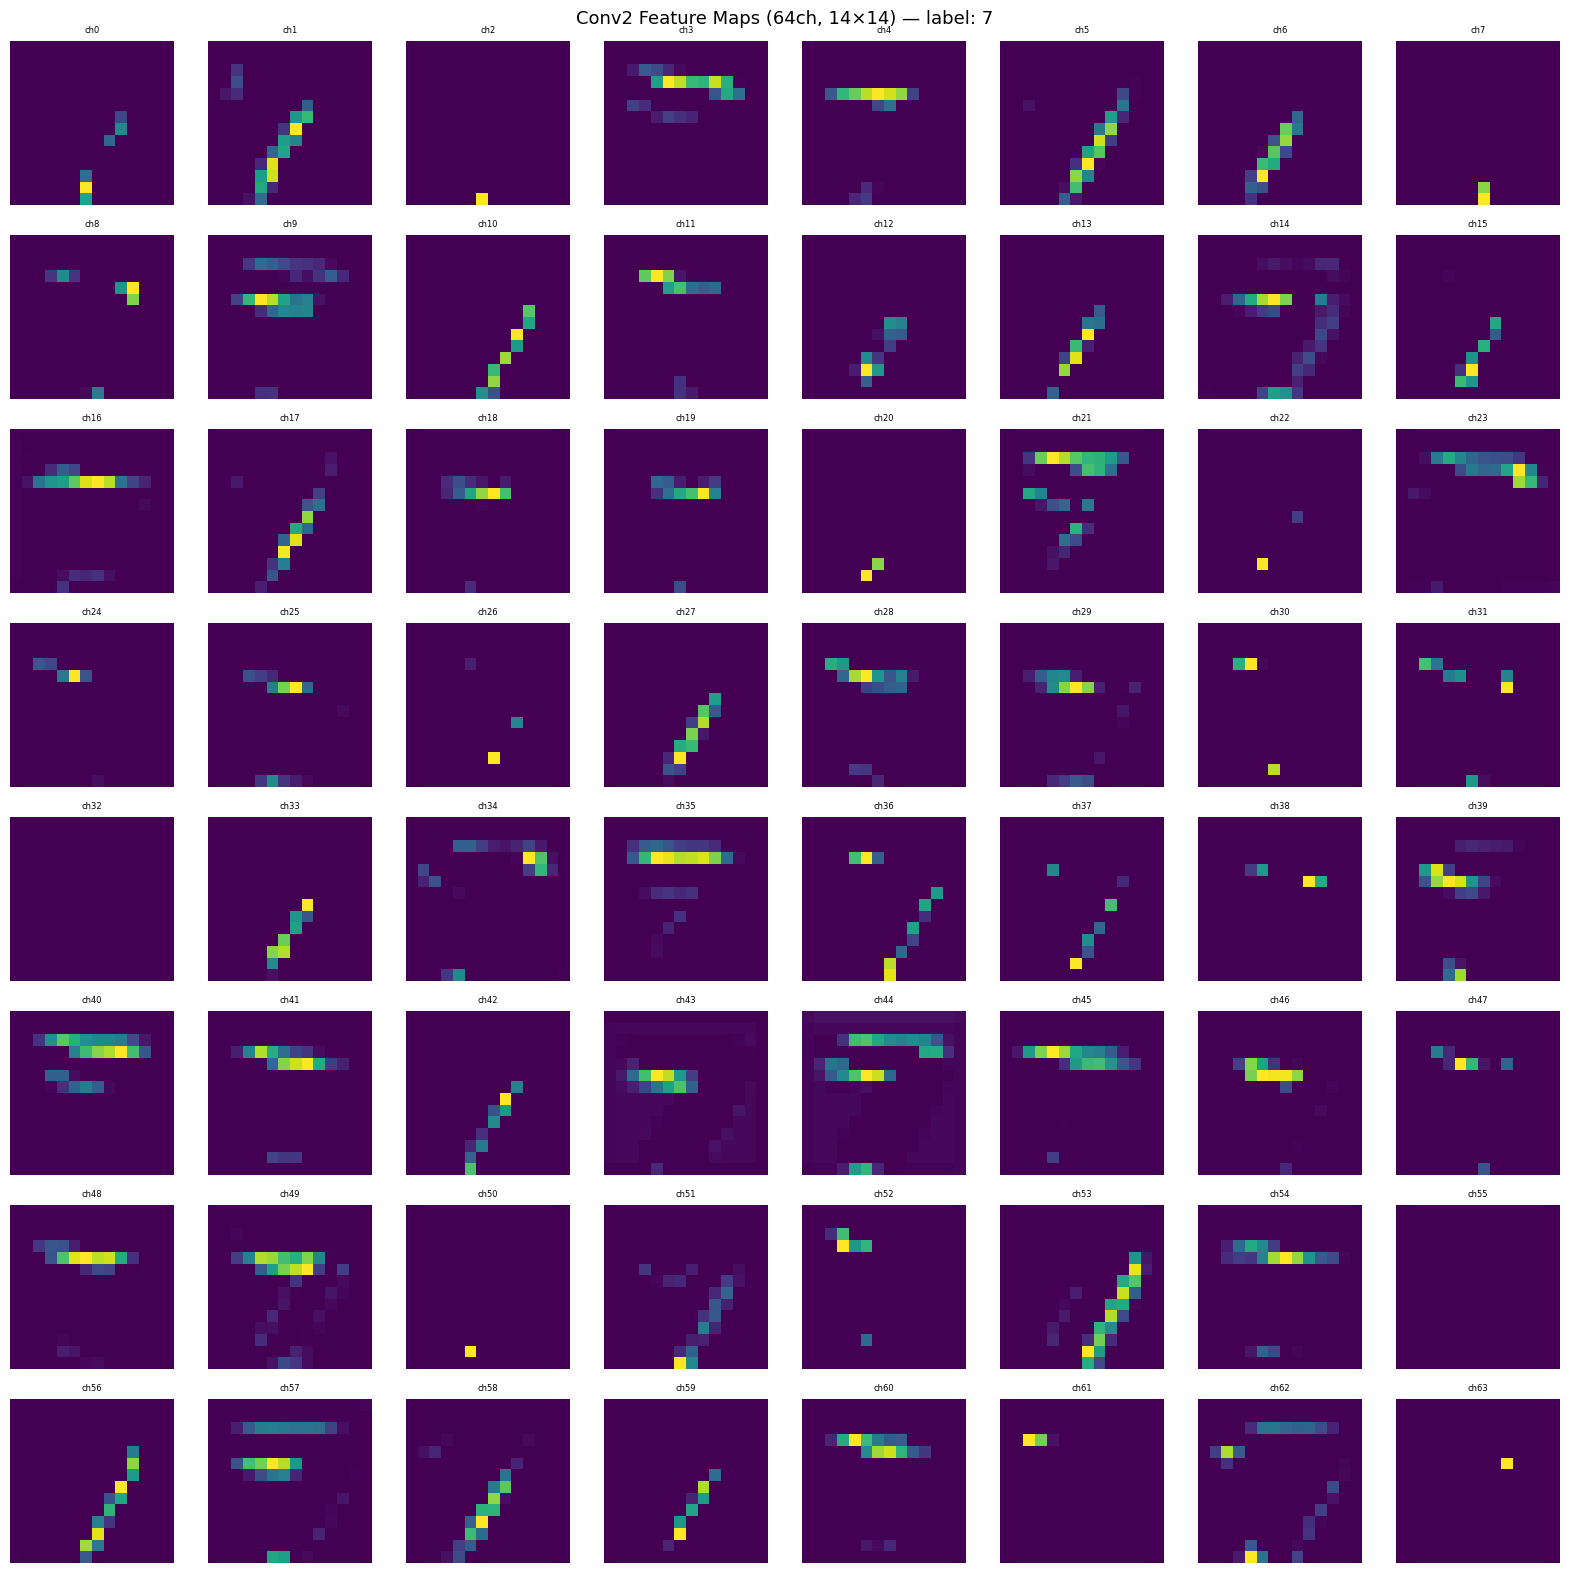

Conv2 特徴マップ shape: (64, 14, 14)  (ch, H, W)


In [14]:
# Cell 11 — 特徴マップ可視化（Conv2）
fm2 = torch.relu(conv2_out['out']).squeeze(0).cpu().numpy()  # (64, 14, 14)

# 64 チャンネルを 8×8 グリッドで表示
fig, axes = plt.subplots(8, 8, figsize=(16, 16))
fig.suptitle(f'Conv2 Feature Maps (64ch, 14×14) — label: {sample_lbl}', fontsize=13)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fm2[i], cmap='viridis')
    ax.set_title(f'ch{i}', fontsize=6)
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Conv2 特徴マップ shape: {fm2.shape}  (ch, H, W)")

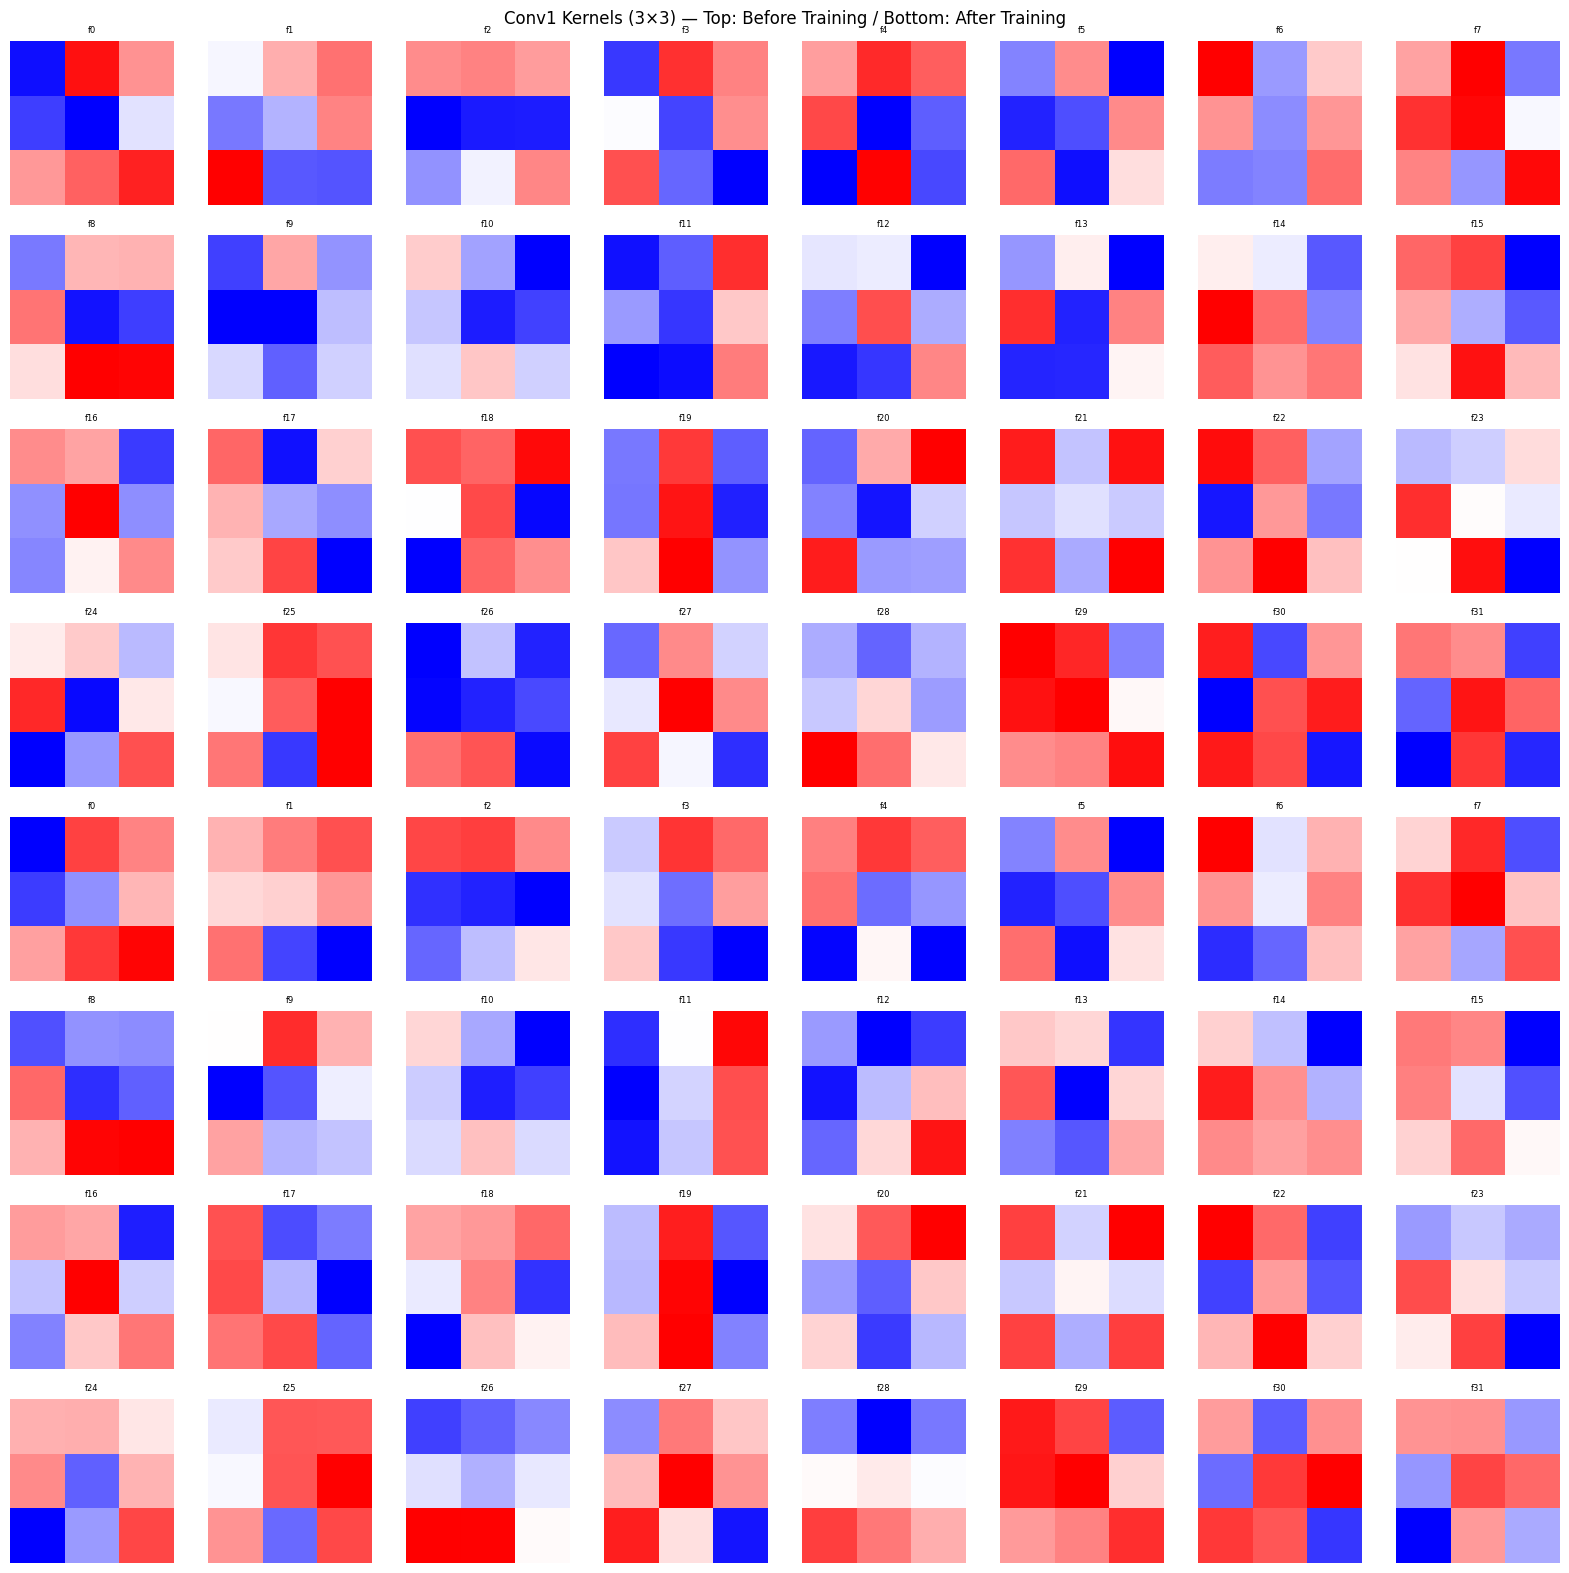

Conv1 weight shape: (32, 1, 3, 3)  (out_ch, in_ch, kH, kW)


In [15]:
# Cell 12 — カーネル可視化（学習前後の比較）
# Conv1 の重み shape: (32, 1, 3, 3)
learned_weight = model.conv1.weight.data.cpu().numpy()   # 学習後
init_weight    = init_conv1_weight.cpu().numpy()          # 学習前（Cell 8 で保存）

def plot_kernels(weights, title, axes_row):
    """32 個の 3×3 カーネルを 4×8 グリッドで描画"""
    for i, ax in enumerate(axes_row.flatten()):
        k = weights[i, 0]  # (3, 3)
        vmax = max(abs(k.min()), abs(k.max()))
        ax.imshow(k, cmap='bwr', vmin=-vmax, vmax=vmax)
        ax.set_title(f'f{i}', fontsize=6)
        ax.axis('off')

fig, axes = plt.subplots(8, 8, figsize=(16, 16))
top_axes    = axes[:4]   # 上 4 行: 学習前
bottom_axes = axes[4:]   # 下 4 行: 学習後

plot_kernels(init_weight,    'Before Training', top_axes)
plot_kernels(learned_weight, 'After Training',  bottom_axes)

fig.suptitle('Conv1 Kernels (3×3) — Top: Before Training / Bottom: After Training', fontsize=12)
plt.tight_layout()
plt.show()
print(f"Conv1 weight shape: {learned_weight.shape}  (out_ch, in_ch, kH, kW)")

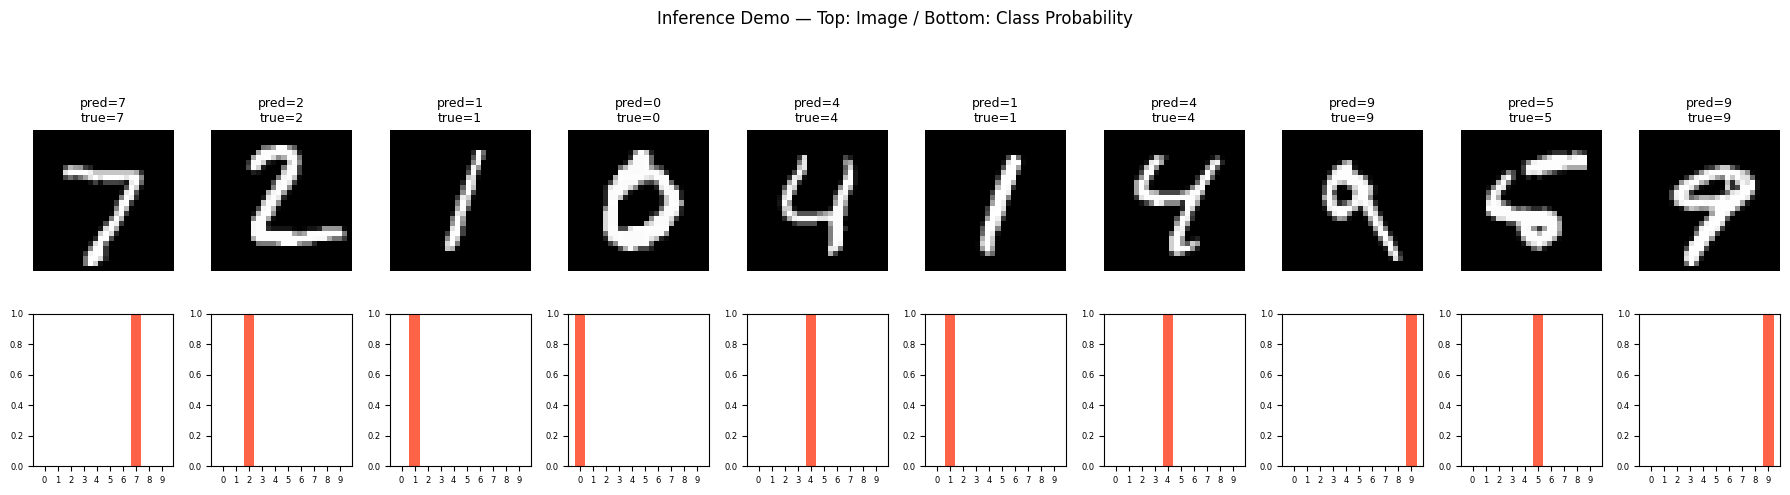

10 枚すべて正解!


In [16]:
# Cell 13 — 推論デモ（テスト画像 10 枚）
model.eval()
n_demo = 10
indices = np.arange(n_demo)

demo_x = test_ds.x[indices].to(device)  # (10, 1, 28, 28)
demo_y = test_labels[indices]

with torch.no_grad():
    logits = model(demo_x)                              # (10, 10)
    probs  = torch.softmax(logits, dim=1).cpu().numpy()  # (10, 10)
    preds  = logits.argmax(dim=1).cpu().numpy()          # (10,)

fig, axes = plt.subplots(2, n_demo, figsize=(18, 5),
                          gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Inference Demo — Top: Image / Bottom: Class Probability', fontsize=12)

for i in range(n_demo):
    # 上段: 画像
    ax_img = axes[0, i]
    ax_img.imshow(test_images[i], cmap='gray')
    color = 'red' if preds[i] != demo_y[i] else 'black'
    ax_img.set_title(f"pred={preds[i]}\ntrue={demo_y[i]}",
                     fontsize=9, color=color)
    ax_img.axis('off')

    # 下段: 確率バー
    ax_bar = axes[1, i]
    bar_colors = ['tomato' if j == preds[i] else 'steelblue' for j in range(10)]
    ax_bar.bar(range(10), probs[i], color=bar_colors)
    ax_bar.set_xticks(range(10))
    ax_bar.set_xticklabels(range(10), fontsize=6)
    ax_bar.set_ylim(0, 1)
    ax_bar.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.show()

errors = np.where(preds != demo_y)[0]
if len(errors) == 0:
    print("10 枚すべて正解!")
else:
    print(f"誤分類: index {list(errors)} — pred={preds[errors]}, true={demo_y[errors]}")

## まとめ

### テンソル形状変化の総復習

| 層 | 出力 shape | 特徴 |
|---|---|---|
| 入力 | `(N, 1, 28, 28)` | グレースケール 1ch |
| Conv1 + ReLU | `(N, 32, 28, 28)` | padding=1 で空間サイズ保持 |
| MaxPool2d | `(N, 32, 14, 14)` | 1/2 にダウンサンプル |
| Conv2 + ReLU | `(N, 64, 14, 14)` | チャンネル数 2 倍 |
| MaxPool2d | `(N, 64, 7, 7)` | さらに 1/2 |
| flatten | `(N, 3136)` | 64×7×7=3136 |
| FC1 + ReLU | `(N, 128)` | 次元圧縮 |
| FC2 (logits) | `(N, 10)` | 10 クラス |

### このノートブックで体験したこと

1. **Conv2d の padding** により空間サイズを維持しながら特徴抽出できることを確認
2. **MaxPool2d** が空間サイズを半分にし、受容野を広げることを確認
3. **5 エポック** の学習で MNIST テスト精度 ≥ 98% を達成
4. **特徴マップ可視化** で Conv1 が低レベルな特徴（エッジ等）を、Conv2 が中レベルな特徴を学習していることを確認
5. **カーネル重み** が学習前後で変化し、構造化されたパターンを獲得することを確認

### 次に学ぶこと

- **Batch Normalization** — 各層の出力を正規化して学習を安定化・高速化
- **Dropout** — ランダムにニューロンを無効化して過学習を防ぐ
- **Data Augmentation** — ランダム回転・クロップ等でデータを水増しして汎化性能を向上
- **Learning Rate Scheduler** — エポック数に応じて学習率を調整
- **より深いネットワーク** — VGG / ResNet などの実用的なアーキテクチャへ